In [39]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from loguru import logger
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tiktoken

In [40]:
ROOT_PATH = Path.cwd().parent
RAW_DATA_PATH = ROOT_PATH / "data" / "raw"
REPORT_PATH = ROOT_PATH / "reports"
TOKENIZER = tiktoken.get_encoding("cl100k_base")

In [41]:
HEADERS_TO_SPLIT_ON = [
    ("#", "Entity"),
    ("##", "Section")
]

In [42]:
def count_tokens(text: str) -> int:
    """Returns the exact number of tokens in a text string."""
    return len(TOKENIZER.encode(text))

In [43]:
def extract_with_langchain() -> pd.DataFrame:
    """
    Uses the production LangChain Splitter to chunk documents and measure exact token lengths.
    """
    # 1. Load the document exactly as you will in the pipeline
    # 2. Split the document using the ACTUAL LangChain tool
    # 3. Analyze the outputted chunks
    logger.info("Initializing LangChain MarkdownHeaderTextSplitter.")
    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=HEADERS_TO_SPLIT_ON)

    md_files = list(RAW_DATA_PATH.glob("*.[mM][dD]"))
    chunk_data = []

    for file_path in md_files:
        try:
            loader = TextLoader(str(file_path), encoding="utf-8")
            docs = loader.load()
            raw_text = docs[0].page_content

            chunks = markdown_splitter.split_text(raw_text)

            for chunk in chunks:
                metadata = chunk.metadata

                entity_name = metadata.get("Entity", "Unknown Entity")
                section_name = metadata.get("Section", "Intro/Floating Text")

                tokens = count_tokens(chunk.page_content)

                chunk_data.append({
                    "File": file_path.name,
                    "Entity": entity_name,
                    "Section": section_name,
                    "Tokens": tokens
                })

        except Exception as e:
            logger.error(f"Failed to process {file_path.name}: {e}")

    return pd.DataFrame(chunk_data)

In [44]:
def generate_eda_report(df: pd.DataFrame):
    """Generates the statistical tables and plots for the Word document."""
    logger.info("Generating EDA Statistics.")

    # Group by the Section to find the heaviest data blocks
    stats_df = (df.groupby("Section")["Tokens"].agg(Count='count',
                                                    Min='min',
                                                    Median='median',
                                                    Mean='mean',
                                                    Max='max',
                                                    Std_Dev='std'
                                                    ).round(2).sort_values(by="Max", ascending=False))

    print("Token length statistics")
    print(stats_df.to_string())

    # Generate the Boxplot Visualization
    logger.info("Rendering Token Distribution Plot.")
    plt.figure(figsize=(14, 8))

    ax = sns.boxplot(x="Tokens", y="Section", data=df)

    plt.title("Distribution of LangChain Chunk Token Lengths", fontsize=16, pad=20)
    plt.xlabel("Number of Tokens (cl100k_base)", fontsize=12)
    plt.ylabel("Document Section (Metadata Key)", fontsize=12)

    plt.axvline(x=512,
                linestyle='--',
                color='red',
                linewidth=2,
                label="Standard Embedding Limit (512 tokens)")
    plt.legend()

    plt.legend()
    plt.tight_layout()
    plot_path = REPORT_PATH / "langchain_token_distribution.pdf"
    plt.savefig(plot_path, format='pdf')
    logger.success(f"Plot saved successfully as '{plot_path}'!")

In [45]:
df_chunks = extract_with_langchain()

2026-03-10 01:40:03.979 | INFO     | __main__:extract_with_langchain:8 - Initializing LangChain MarkdownHeaderTextSplitter.


2026-03-10 01:40:07.696 | INFO     | __main__:generate_eda_report:3 - Generating EDA Statistics.
2026-03-10 01:40:07.698 | INFO     | __main__:generate_eda_report:18 - Rendering Token Distribution Plot.


Token length statistics
                                                                    Count   Min  Median     Mean   Max  Std_Dev
Section                                                                                                        
Sessions                                                               56     8  3117.5  2963.11  8221  1819.35
Constructive questions                                                 56     8     8.0   921.36  7435  1683.73
General information                                                    64     8   658.5   793.64  3199   597.74
Curriculum details                                                      3  1905  1924.0  1917.67  1924    10.97
Learning outcomes                                                      56     8   227.5   305.29  1663   287.71
CLOs-PLOs maps                                                         56     8   371.0   333.88  1226   234.06
Assignments and assessments                                            56     8 

2026-03-10 01:40:07.926 | SUCCESS  | __main__:generate_eda_report:38 - Plot saved successfully as 'C:\Users\dduya\Work\project\flm_agent\reports\langchain_token_distribution.pdf'!


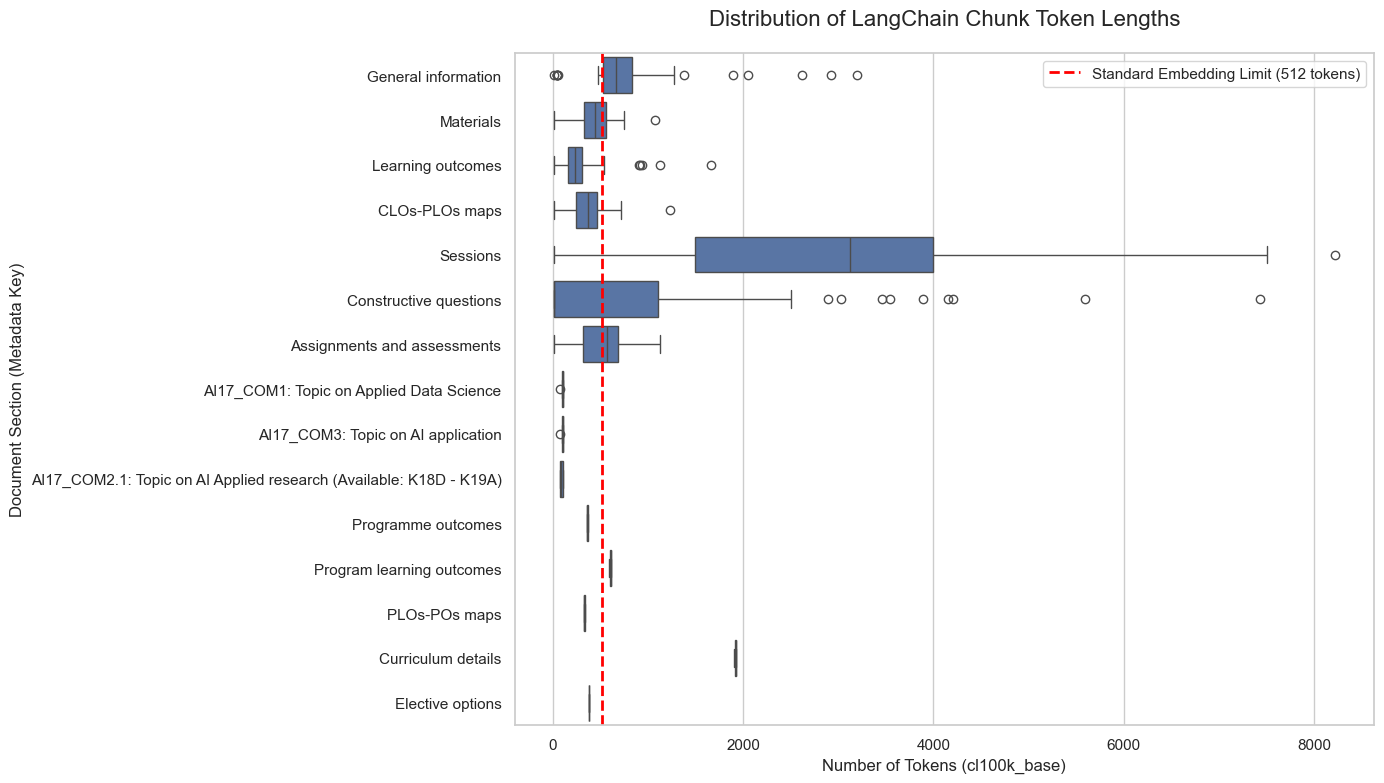

In [46]:
generate_eda_report(df_chunks)